In [34]:
import warnings
warnings.filterwarnings('ignore')

In [139]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
import subprocess
from tqdm import tqdm_notebook
import pprint
import yaml
from multiprocessing import Pool
from IPython.display import clear_output
from scipy import ndimage
from skimage.transform import rotate
import pickle

import music21
import madmom

In [41]:
# path to real dataset
DATA_ROOT_REAL = '../real_dataset'

# Synthesize Audio from MIDI

In [42]:
# Get all MIDI files
files = glob.glob(os.path.join(DATA_ROOT_REAL, 'midi', '*'))

In [43]:
if not os.path.exists(os.path.join(DATA_ROOT_REAL, 'audio')):
    os.mkdir(os.path.join(DATA_ROOT_REAL, 'audio'))

In [44]:
def processPiece(file_idx):
    midi_file = files[file_idx]
    soundfont_file = './soundfonts/grand-piano-YDP-20160804.sf2'
    output_file = os.path.join(DATA_ROOT_REAL, 'audio', os.path.splitext(os.path.basename(midi_file))[0] +  '.flac')
    
    # Generate audio file
    subprocess.call(["fluidsynth", '-F', output_file, '-O', 's16', '-T', 'flac', 
                     soundfont_file, midi_file])

In [45]:
with Pool(12) as p:
    list(tqdm_notebook(p.imap(processPiece, range(len(files))), total=len(files)))

HBox(children=(IntProgress(value=0, max=22), HTML(value='')))

# Generate Spectrogram

In [46]:
# Get all audio files
files = glob.glob(os.path.join(DATA_ROOT_REAL, 'audio', '*'))

In [47]:
SAMPLING_FREQUENCY = 22050
FRAME_SIZE = 2048
FPS = 20

In [48]:
def calcBin(f, R=100, base=0, base_ref=27.5):
    """
    Calculate the bin frequencies
    """
    return (np.round(1200 / R * np.log2(f/base_ref) + base)).astype(np.int)

In [49]:
def notes_to_onsets(notes, dt):
    """ Convert sequence of keys to onset frames """

    onsets = []
    for n in notes:
        onset = int(np.ceil(n[0] / dt))
        onsets.append(onset)

    return np.sort(np.asarray(onsets)).astype(np.float32)

In [65]:
def generateSpec(file_idx, debug=False):
    sig_proc = madmom.audio.signal.SignalProcessor(sample_rate=SAMPLING_FREQUENCY, num_channels=1)
    fsig_proc = madmom.audio.signal.FramedSignalProcessor(frame_size=FRAME_SIZE, fps=FPS, origin='future')
    spec_proc = madmom.audio.spectrogram.SpectrogramProcessor()
    
    audio_file = files[file_idx]
    midi_file = audio_file.replace('/audio/','/midi/').replace('.flac','.mid')

    if debug: print(midi_file, audio_file)
    
    # Compute salience representation
    sig = sig_proc(audio_file)
    sig = fsig_proc(sig)
    spec = spec_proc(sig)

    n_frames = spec.shape[0]
    salience = np.zeros((88, n_frames))

    fk = np.arange(spec.shape[1]) / FRAME_SIZE * SAMPLING_FREQUENCY
    dft_indices = calcBin(fk)
    for k in range(88):
        salience[k, :] = np.sum(spec.T[dft_indices == k,:], axis=0)

    if not os.path.exists(os.path.join(DATA_ROOT_REAL, 'spec')):
        os.mkdir(os.path.join(DATA_ROOT_REAL, 'spec'))

    spec_file_path = os.path.join(DATA_ROOT_REAL, 'spec', os.path.splitext(os.path.basename(audio_file))[0]) + '_spec.npy'
    np.save(spec_file_path, salience)

    if debug:
        plt.imshow(salience, aspect='auto', cmap='hot')
        plt.show()
            

    # Compute onset
    s = music21.midi.translate.midiFilePathToStream(midi_file)
    mf = music21.midi.translate.streamToMidiFile(s)
    n_tracks = len(mf.tracks)

    onsets = None
    for i_track, track in enumerate(mf.tracks[0:1]):
        m = madmom.utils.midi.MIDIFile.from_file(midi_file)

        notes =  np.asarray(sorted(m.notes(), key=lambda n: (n[0], n[1] * -1)))
        onsets = notes_to_onsets(notes, dt=1.0/FPS)

    onsets_file_path = os.path.join(DATA_ROOT_REAL, 'spec', os.path.splitext(os.path.basename(audio_file))[0]) + '_onsets.npy'
    np.save(onsets_file_path, onsets)

In [67]:
with Pool(12) as p:
    list(tqdm_notebook(p.imap(generateSpec, range(len(files))), total=len(files)))

HBox(children=(IntProgress(value=0, max=22), HTML(value='')))

../real_dataset/midi/schubert_op90no3.mid ../real_dataset/audio/schubert_op90no3.flac


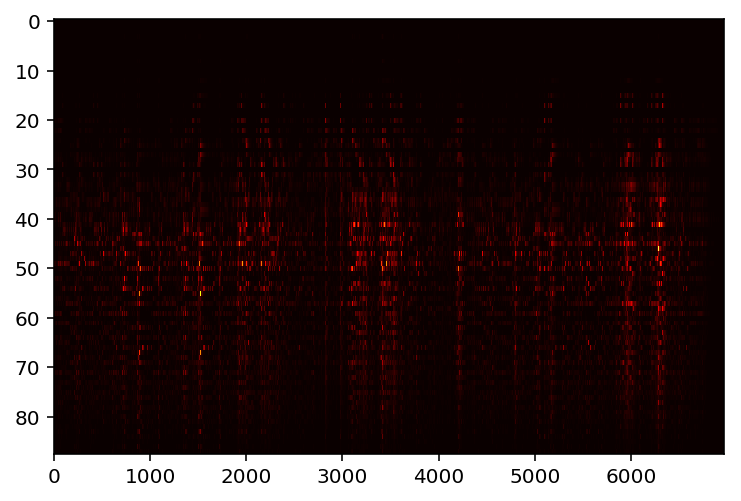

In [64]:
generateSpec(3, debug=True)

# Pre-load all sheet music images

In [114]:
pieces = glob.glob(os.path.join(DATA_ROOT_REAL, 'prepped_png', '*'))

In [115]:
def importBoundaryData(infile):
    d = {}  # key: basename, val: list of boundaries locations
    with open(infile,'r') as f:
        for line in f:
            parts = line.split()
            basename = parts.pop(0)
            bnds = map(lambda x: int(x) * 300 // 72, parts)
            d[basename] = bnds
    return d

In [116]:
def importImage(pngfile):
    img = ndimage.imread(pngfile, flatten=True)
    img = 1 - img/255.0 # make white -> 0, black -> 1
    return img

In [117]:
def rotateToHorizontal(img, lb=-.5, ub=.5, incr=.02, topN=40):
    bestscore = -np.inf
    bestTheta = 0
    for theta in np.arange(lb, ub, incr):
        imgRot = rotate(img,theta)
        rsums = np.sum(imgRot, axis=1)
        rsums_sorted = sorted(rsums)[::-1]
        curscore = np.sum(rsums_sorted[0:topN])
        if curscore > bestscore:
            bestscore = curscore
            bestTheta = theta
    result = rotate(img,bestTheta)
    return result, bestTheta

In [118]:
def getBoundingBox(img, thresh=.01, buff=0.05):
    r = img.shape[0]
    c = img.shape[1]
    
    cmeans = np.mean(img, axis=0)
    cmean_thresh = np.max(cmeans) * thresh
    cidxs_above = np.argwhere(cmeans > cmean_thresh)
    col_start = cidxs_above[0][0]
    col_end = cidxs_above[-1][0]
    
    rmeans = np.mean(img, axis=1)
    rmean_thresh = np.max(rmeans) * thresh
    ridxs_above = np.argwhere(rmeans > rmean_thresh)
    row_start = ridxs_above[0][0]
    row_end = ridxs_above[-1][0]
    
    # add buffer to ignore clefs
    bufflen = np.int((col_end - col_start) * buff)
    col_start_adj = col_start + bufflen
    
    return (row_start, col_start_adj), col_end - col_start_adj, row_end - row_start

In [119]:
def getStrips(X, bnds):
    strips = []
    for i in range(len(bnds)-1):
        rstart = bnds[i]
        rend = bnds[i+1] + 1 # include endpoint
        chunk = X[rstart:rend,:]
        strips.append(chunk)
    return strips

In [120]:
def getCropped(X):
    ll, w, h = getBoundingBox(X)
    return X[ll[0]:ll[0]+h,ll[1]:ll[1]+w]

In [137]:
def convertStripPiece(piece_idx, debug=False):
    piece = pieces[piece_idx]
    d = importBoundaryData(os.path.join(DATA_ROOT_REAL, 'prepped_png', 'bnds.corrected.txt'))
    
    pages = sorted(glob.glob(os.path.join(piece, '*')))
    output = []
    for page in pages:
        if debug: print(page)
        
        # Get strip boundary
        I = importImage(page)
        Irot, theta = rotateToHorizontal(I)
        ll, w, h = getBoundingBox(Irot)
        
        Icrop = getCropped(Irot)
        basename = os.path.splitext(os.path.basename(page))[0]
        
        if debug: print(basename)
        
        bnds = list(d[basename])
        strips = getStrips(Icrop, bnds)
        output.extend(strips)
        
    
    if not os.path.exists(os.path.join(DATA_ROOT_REAL, 'pickle')):
        os.mkdir(os.path.join(DATA_ROOT_REAL, 'pickle'))
        
    with open(piece.replace('/prepped_png/','/pickle/'), 'wb') as f:
        pickle.dump(output, f)
    return output

In [134]:
test = convertStripPiece(0, True)

../real_dataset/prepped_png/clementi_op36no1mv3_v1/clementi_op36no1mv3_v1-0.png
clementi_op36no1mv3_v1-0
1
1
../real_dataset/prepped_png/clementi_op36no1mv3_v1/clementi_op36no1mv3_v1-1.png
clementi_op36no1mv3_v1-1
7
8


In [140]:
with Pool(12) as p:
    list(tqdm_notebook(p.imap(convertStripPiece, range(len(pieces))), total=len(pieces)))

HBox(children=(IntProgress(value=0, max=69), HTML(value='')))